# Selective Inference: A(Li)–vsini Relation in Upper Sco

Tests whether the A(Li)–vsini relation survives variable selection correction.

**Methods used:**
1. Forward stepwise with AIC/BIC stopping rules
2. All-subsets regression
3. Lasso with cross-validation
4. Stability selection (resampled lasso)
5. Pre-specified nested F-tests for vsini

**Expected input:** `uppersco_data.csv` with columns `vsini, vmic, teff, g, sagitta_age, fe_h, a_li, logg`

## 1. Setup and data loading

Both predictors and response are standardized to mean=0, sd=1. This means:
- Coefficients are comparable across variables on the same scale
- A coefficient of $\beta$ means: one sd increase in predictor -> $\beta$ sd change in A(Li)
- To convert back to physical units: $\beta_{phys} = \beta_{std} \cdot sd(y) / sd(X_j)$

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import smplotlib  # noqa: F401 - applies publication-quality matplotlib style on import
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from itertools import combinations
from scipy.stats import f as f_dist

# Path for saving figures to Desktop
DESKTOP = os.path.expanduser('/Users/melindasoares/Desktop/')

In [5]:
# Update this path to your local file
df = pd.read_csv('260416_uppersco_data.csv', index_col=0)

# Drop 'g' entirely; keep 'logg' (surface gravity in log cgs).
# The 'g' column is heavily skewed and redundant with logg for our purposes.
df = df.drop(columns=['g'])

response_col = 'a_li'
X_df = df.drop(columns=[response_col]).copy()
y_raw = df[response_col].values
predictor_names = list(X_df.columns)
n = len(y_raw)
p = len(predictor_names)

print(f'N = {n}, predictors = {predictor_names}')
df.describe()

N = 66, predictors = ['vsini', 'vmic', 'teff', 'sagitta_age', 'fe_h', 'logg']


,vsini,vmic,teff,sagitta_age,fe_h,a_li,logg
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,17.736632,1.268228,4675.185135,6.427940,-0.262587,2.267053,4.083537
std,6.911518,0.529073,422.226995,0.518073,0.309282,0.602243,0.276971
min,4.956780,0.293037,4071.062700,5.241165,-1.450131,-0.301019,3.561213
25%,11.756459,0.953340,4339.876850,6.157779,-0.287243,1.899032,3.882959
50%,17.917962,1.306326,4663.903150,6.646270,-0.173718,2.422862,4.056356
75%,22.896026,1.563824,4810.884500,6.735770,-0.084750,2.633958,4.271321
max,34.920850,3.312578,5962.374500,7.316730,0.079692,3.492798,4.905314


In [6]:
# Standardize predictors AND response (mean=0, sd=1)
X_scaler = StandardScaler()
X = X_scaler.fit_transform(X_df.values)

y_scaler = StandardScaler()
y = y_scaler.fit_transform(y_raw.reshape(-1, 1)).ravel()

print(f'X shape: {X.shape},  mean = {X.mean():.3e},  sd = {X.std():.3f}')
print(f'y shape: {y.shape},  mean = {y.mean():.3e},  sd = {y.std():.3f}')
print(f'\nOriginal y scale for later back-transform:')
print(f'  y mean = {y_raw.mean():.4f},  y sd = {y_raw.std(ddof=0):.4f}')

X shape: (66, 6),  mean = 1.727e-16,  sd = 1.000
y shape: (66,),  mean = 3.095e-16,  sd = 1.000

Original y scale for later back-transform:
  y mean = 2.2671,  y sd = 0.5977


## 2. Forward stepwise with AIC/BIC stopping

In [7]:
selected = []
remaining = list(range(p))
aics, bics, rsss = [], [], []

for step in range(p):
    best_rss = np.inf
    best_var = None
    for v in remaining:
        cols = selected + [v]
        Xk = X[:, cols]
        beta, *_ = np.linalg.lstsq(Xk, y, rcond=None)
        rss = np.sum((y - Xk @ beta)**2)
        if rss < best_rss:
            best_rss = rss
            best_var = v
    selected.append(best_var)
    remaining.remove(best_var)
    k = len(selected)
    loglik = -n/2 * (np.log(2*np.pi*best_rss/n) + 1)
    aics.append(-2*loglik + 2*k)
    bics.append(-2*loglik + np.log(n)*k)
    rsss.append(best_rss)

fs_table = pd.DataFrame({
    'step': range(1, p+1),
    'added': [predictor_names[v] for v in selected],
    'RSS': rsss,
    'AIC': aics,
    'BIC': bics
})
fs_table

,step,added,RSS,AIC,BIC
0,1,vmic,48.712240,169.254076,171.443731
1,2,teff,43.907722,164.400626,168.779936
2,3,vsini,38.998888,158.575860,165.144824
3,4,logg,38.428311,159.603107,168.361726
4,5,fe_h,37.685589,160.315006,171.263279
5,6,sagitta_age,37.374021,161.767078,174.905007


In [8]:
aic_stop = np.argmin(aics) + 1
bic_stop = np.argmin(bics) + 1
print(f'AIC minimum: step {aic_stop} -> {[predictor_names[v] for v in selected[:aic_stop]]}')
print(f'BIC minimum: step {bic_stop} -> {[predictor_names[v] for v in selected[:bic_stop]]}')

AIC minimum: step 3 -> ['vmic', 'teff', 'vsini']
BIC minimum: step 3 -> ['vmic', 'teff', 'vsini']


## 3. All-subsets regression

In [9]:
results = []
for k in range(1, p + 1):
    for combo in combinations(range(p), k):
        Xk = X[:, list(combo)]
        beta, *_ = np.linalg.lstsq(Xk, y, rcond=None)
        rss = np.sum((y - Xk @ beta)**2)
        loglik = -n/2 * (np.log(2*np.pi*rss/n) + 1)
        aic = -2*loglik + 2*k
        bic = -2*loglik + np.log(n)*k
        results.append({'BIC': bic, 'AIC': aic, 'k': k,
                        'vars': [predictor_names[i] for i in combo],
                        'indices': combo})

all_subsets_df = pd.DataFrame(results).sort_values('BIC').reset_index(drop=True)
all_subsets_df.head(10)

,BIC,AIC,k,vars,indices
0,165.144824,158.575860,3,"[vsini, vmic, teff]","(0, 1, 2)"
1,168.361726,159.603107,4,"[vsini, vmic, teff, logg]","(0, 1, 2, 5)"
2,168.779936,164.400626,2,"[vmic, teff]","(1, 2)"
3,169.117183,160.358564,4,"[vsini, vmic, teff, fe_h]","(0, 1, 2, 4)"
4,169.308548,160.549929,4,"[vsini, vmic, teff, sagitta_age]","(0, 1, 2, 3)"
5,171.263279,160.315006,5,"[vsini, vmic, teff, fe_h, logg]","(0, 1, 2, 4, 5)"
6,171.443731,169.254076,1,[vmic],"(1,)"
7,171.661213,165.092249,3,"[vmic, teff, fe_h]","(1, 2, 4)"
8,172.175579,161.227305,5,"[vsini, vmic, teff, sagitta_age, logg]","(0, 1, 2, 3, 5)"
9,172.631022,166.062058,3,"[vmic, teff, logg]","(1, 2, 5)"


In [10]:
# How often does each variable appear in the top-20 models by BIC?
top20 = all_subsets_df.head(20)
appearance = {name: sum(name in row for row in top20['vars']) for name in predictor_names}
appearance_df = pd.DataFrame.from_dict(appearance, orient='index',
                                       columns=['count_in_top20']).sort_values(
    'count_in_top20', ascending=False)
appearance_df

,count_in_top20
vmic,20
teff,13
vsini,10
logg,9
fe_h,8
sagitta_age,6


## 4. Lasso with cross-validation

In [11]:
lasso = LassoCV(cv=10, random_state=42, max_iter=50000).fit(X, y)
print(f'Optimal alpha: {lasso.alpha_:.5f}')

lasso_df = pd.DataFrame({
    'predictor': predictor_names,
    'coefficient': lasso.coef_,
    'selected': np.abs(lasso.coef_) > 1e-6
}).sort_values('coefficient', key=abs, ascending=False)
lasso_df

Optimal alpha: 0.11026


,predictor,coefficient,selected
1,vmic,0.347228,True
2,teff,0.225169,True
0,vsini,-0.146319,True
4,fe_h,0.000020,True
3,sagitta_age,0.000000,False
5,logg,0.000000,False


## 5. Stability selection

In [12]:
rng = np.random.default_rng(42)
n_boot = 500
subsample_frac = 0.75
selection_counts = np.zeros(p)

for _ in range(n_boot):
    idx = rng.choice(n, size=int(n * subsample_frac), replace=False)
    lasso_b = Lasso(alpha=lasso.alpha_, max_iter=50000).fit(X[idx], y[idx])
    selection_counts += (np.abs(lasso_b.coef_) > 1e-6).astype(int)

selection_freq = selection_counts / n_boot
stab_df = pd.DataFrame({
    'predictor': predictor_names,
    'selection_frequency': selection_freq
}).sort_values('selection_frequency', ascending=False).reset_index(drop=True)
stab_df

,predictor,selection_frequency
0,teff,1.000
1,vmic,0.998
2,vsini,0.994
3,fe_h,0.578
4,logg,0.548
5,sagitta_age,0.052


Saved to /Users/melindasoares/Desktop/stability_selection.pdf


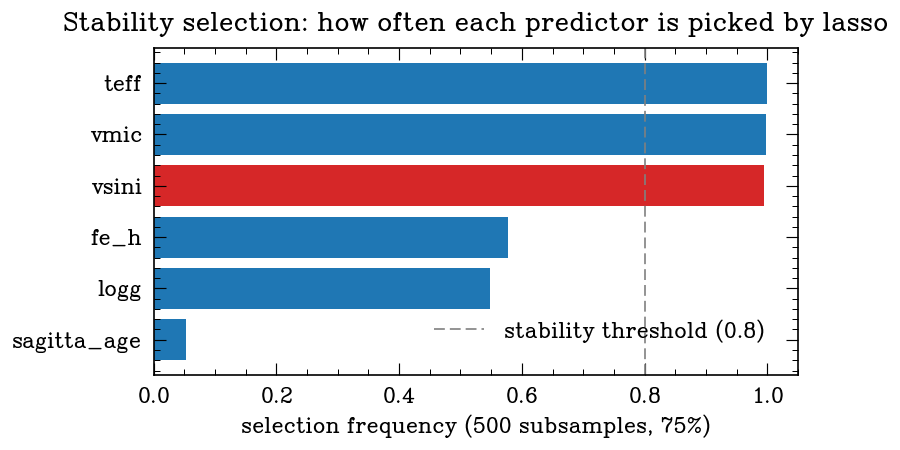

In [13]:
# Stability selection plot
fig, ax = plt.subplots(figsize=(7, 4))
order = np.argsort(selection_freq)
colors = ['#d62728' if predictor_names[i] == 'vsini' else '#1f77b4' for i in order]
ax.barh([predictor_names[i] for i in order], selection_freq[order], color=colors)
ax.axvline(0.8, color='gray', ls='--', lw=1, label='stability threshold (0.8)')
ax.set_xlabel('selection frequency (500 subsamples, 75%)')
ax.set_title('Stability selection: how often each predictor is picked by lasso')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()

# Save to Desktop
outpath = os.path.join(DESKTOP, 'stability_selection.pdf')
plt.savefig(outpath, bbox_inches='tight', dpi=300)
plt.savefig(outpath.replace('.pdf', '.png'), bbox_inches='tight', dpi=300)
print(f'Saved to {outpath}')
plt.show()

## 6. Pre-specified nested tests for vsini

These are not subject to selection bias because the tests are specified in advance. This is the cleanest evidence for a paper.

In [14]:
def rss_of(Xk, y):
    beta, *_ = np.linalg.lstsq(Xk, y, rcond=None)
    return np.sum((y - Xk @ beta)**2), beta

def nested_F(small_cols, big_cols):
    Xs = X[:, small_cols] if small_cols else np.zeros((n, 0))
    Xb = X[:, big_cols]
    rss_s, _ = rss_of(Xs, y) if small_cols else (np.sum(y**2), None)
    rss_b, beta_b = rss_of(Xb, y)
    df_num = len(big_cols) - len(small_cols)
    df_den = n - len(big_cols) - 1
    F = ((rss_s - rss_b) / df_num) / (rss_b / df_den)
    pval = 1 - f_dist.cdf(F, df_num, df_den)
    return F, pval, beta_b

vsini_i = predictor_names.index('vsini')
teff_i = predictor_names.index('teff')
age_i = predictor_names.index('sagitta_age')

tests = []

# Test 1: vsini alone
F, pval, beta = nested_F([], [vsini_i])
tests.append({'test': 'vsini alone', 'F': F, 'p-value': pval,
              'vsini_coef': beta[0]})

# Test 2: vsini added to teff
F, pval, beta = nested_F([teff_i], [teff_i, vsini_i])
tests.append({'test': 'vsini | teff', 'F': F, 'p-value': pval,
              'vsini_coef': beta[1]})

# Test 3: vsini added to [teff, age]
F, pval, beta = nested_F([teff_i, age_i], [teff_i, age_i, vsini_i])
tests.append({'test': 'vsini | teff, age', 'F': F, 'p-value': pval,
              'vsini_coef': beta[2]})

# Test 4: vsini added to full model
others = [i for i in range(p) if i != vsini_i]
F, pval, beta = nested_F(others, others + [vsini_i])
tests.append({'test': 'vsini | all others', 'F': F, 'p-value': pval,
              'vsini_coef': beta[-1]})

tests_df = pd.DataFrame(tests)
tests_df

,test,F,p-value,vsini_coef
0,vsini alone,3.530044,0.064822,-0.228634
1,vsini | teff,9.718033,0.002749,-0.355889
2,"vsini | teff, age",9.571825,0.002962,-0.356161
3,vsini | all others,6.447569,0.013767,-0.272054


## 7. Summary

In [15]:
print('=' * 60)
print('SUMMARY: A(Li)-vsini relation in Upper Sco')
print('=' * 60)
print(f'N = {n} stars, {p} candidate predictors\n')

print(f'Forward stepwise entry order: '
      f'{" -> ".join(predictor_names[v] for v in selected[:bic_stop])}')
print(f'AIC/BIC both select: {[predictor_names[v] for v in selected[:bic_stop]]}\n')

print(f'Best model by BIC (all-subsets): {list(all_subsets_df.iloc[0]["vars"])}')
print(f'vsini appears in {appearance["vsini"]}/20 top-BIC models\n')

print(f'Stability selection frequency for vsini: '
      f'{stab_df[stab_df.predictor == "vsini"].iloc[0].selection_frequency:.3f}\n')

print('Pre-specified F-tests for vsini:')
for row in tests:
    print(f'  {row["test"]:25s}  coef = {row["vsini_coef"]:+.4f}  '
          f'p = {row["p-value"]:.4f}')

SUMMARY: A(Li)-vsini relation in Upper Sco
N = 66 stars, 6 candidate predictors

Forward stepwise entry order: vmic -> teff -> vsini
AIC/BIC both select: ['vmic', 'teff', 'vsini']

Best model by BIC (all-subsets): ['vsini', 'vmic', 'teff']
vsini appears in 10/20 top-BIC models

Stability selection frequency for vsini: 0.994

Pre-specified F-tests for vsini:
  vsini alone                coef = -0.2286  p = 0.0648
  vsini | teff               coef = -0.3559  p = 0.0027
  vsini | teff, age          coef = -0.3562  p = 0.0030
  vsini | all others         coef = -0.2721  p = 0.0138
